 # Deep Learning - Assignment 3
 ## Lyrics Generation using RNNs

 **Student Names:** Yuriy Rusanov, Elad Orpaz

 **ID(s):** 340915149, 206216517

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import Counter
import matplotlib.pyplot as plt
import pretty_midi
import os
import re
import random
from tqdm import tqdm
import gensim.downloader as api
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

In [2]:
# For reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
midi_files_dir = 'data/midi_files'

print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")

PyTorch Version: 2.5.1
CUDA Available: True


## 1. Data Preparation

### 1.1. Data Loading and Preprocessing

In [3]:
# Load lyrics data
def load_lyrics_data(file_path):
    """Load Lyrics data from CSV file"""
    df = pd.read_csv(file_path, header=None, usecols=[0, 1, 2])
    df.columns = ['artist', 'song', 'lyrics']
    return df


def is_problematic(row):
    # List of known problematic files (patterns to match in filenames)
    problematic_patterns = [
        ('beastie boys', 'girls'),
        ('billy joel', 'movin\' out'),
        ('billy joel', 'pressure'),
        ('dan fogelberg', 'leader of the band'),
        ('brian mcknight', 'on the down low'),
        ('aaron neville', 'tell it like it is'),
    ]

    return (row['artist'].lower(), row['song'].lower()) in problematic_patterns


train_lyrics = load_lyrics_data('data/lyrics_train_set.csv')
train_lyrics = train_lyrics[~train_lyrics.apply(is_problematic, axis=1)].reset_index(drop=True)

test_lyrics = load_lyrics_data('data/lyrics_test_set.csv')

print("Training data shape:", train_lyrics.shape)
print("Test data shape:", test_lyrics.shape)

Training data shape: (594, 3)
Test data shape: (5, 3)


### 1.2. Tokenization

In [4]:
def preprocess_lyrics(lyrics_series):
    """Preprocess and tokenize lyrics."""
    all_lyrics = []
    for lyric in lyrics_series:
        # Convert to lowercase and split into lines
        lyric = str(lyric).lower()
        lines = lyric.split('&')

        # Process each line
        for line in lines:
            # Clean and tokenize
            # tokens = re.findall(r'\b\w+\b', line)
            tokens = re.findall(r"\b\w+(?:'\w+)*\b", line)
            if tokens:  # Skip empty lines
                all_lyrics.append(tokens)

    return all_lyrics


# Process train and test lyrics
train_tokenized = preprocess_lyrics(train_lyrics.iloc[:, 2])
test_tokenized = preprocess_lyrics(test_lyrics.iloc[:, 2])

print(f"Number of lines in training set: {len(train_tokenized)}")
print(f"Number of lines in test set: {len(test_tokenized)}")

Number of lines in training set: 23659
Number of lines in test set: 189


### 1.3. Word Embeddings

In [5]:
def build_vocabulary(tokenized_lyrics, min_freq):
    """Build vocabulary from tokenized lyrics."""
    word_counts = Counter()
    for line in tokenized_lyrics:
        word_counts.update(line)

    vocab = {'<PAD>': 0, '<NEXT LINE>': 1, '<START>': 2, '<END>': 3, '<UNK>': 4}
    idx = 5
    for word, count in word_counts.items():
        if count >= min_freq:
            vocab[word] = idx
            idx += 1

    return vocab, word_counts


vocab, word_counts = build_vocabulary(train_tokenized, min_freq=1)
print(f"Vocabulary size: {len(vocab)}")
print(f"Top 10 most common words: {word_counts.most_common(10)}")

Vocabulary size: 7385
Top 10 most common words: [('you', 5898), ('the', 5805), ('i', 5290), ('to', 3733), ('and', 3654), ('a', 3063), ('me', 2817), ('my', 2161), ('it', 2051), ('in', 2039)]


In [6]:
# Load Pre-trained Word2Vec Model
pretrained_w2v_model = api.load('word2vec-google-news-300')
embedding_dim = pretrained_w2v_model.vector_size

print(f"Pre-trained Word2Vec model loaded with vector size: {embedding_dim}")
print(f"Vocabulary size in pre-trained model: {len(pretrained_w2v_model.key_to_index)}")


def create_embedding_matrix(vocab, embedding_model, embedding_dim):
    """Create embedding matrix for words in vocabulary from a pre-trained model."""
    embedding_matrix = np.zeros((len(vocab), embedding_dim))
    words_in_model = 0
    words_not_in_model = 0

    for word, idx in vocab.items():
        # Check if the word is in the pre-trained model's vocabulary
        if word in embedding_model:
            embedding_matrix[idx] = embedding_model[word]
            words_in_model += 1
        else:
            # For words not in the model and special tokens, initialize randomly
            # This also handles '<START>', '<END>', etc.
            embedding_matrix[idx] = np.random.uniform(-0.25, 0.25, embedding_dim)
            words_not_in_model += 1

    # Ensure the <PAD> token is always all zeros
    embedding_matrix[vocab['<PAD>']] = np.zeros(embedding_dim)

    print(f"Words found in pre-trained model: {words_in_model}")
    print(f"Words not found (initialized randomly): {words_not_in_model}")
    return embedding_matrix


embedding_matrix = create_embedding_matrix(vocab, pretrained_w2v_model, embedding_dim)
print(f"Embedding matrix shape: {embedding_matrix.shape}")

Pre-trained Word2Vec model loaded with vector size: 300
Vocabulary size in pre-trained model: 3000000
Words found in pre-trained model: 6713
Words not found (initialized randomly): 672
Embedding matrix shape: (7385, 300)


### 1.4. Match Lyrics with MIDI Files

In [7]:
def create_lyrics_midi_mapping(lyrics_df, midi_dir):
    """Mapping lyrics to MIDI files."""
    mapping = []

    midi_files = os.listdir(midi_dir)

    # For each song in the lyrics dataset, find the matching MIDI file
    for idx, row in lyrics_df.iterrows():
        artist = row['artist'].strip().lower().replace(' ', '_')
        song = row['song'].strip().lower().replace(' ', '_')
        lyrics = row['lyrics']

        for midi_file in midi_files:
            midi_name = midi_file.lower()
            if artist in midi_name and song in midi_name:
                mapping.append({
                    'artist': artist,
                    'song': song,
                    'lyrics': lyrics,
                    'midi_file': os.path.join(midi_dir, midi_file)
                })
                break

    return mapping


# Create mapping for training and test data
train_mapping = create_lyrics_midi_mapping(train_lyrics, midi_files_dir)
test_mapping = create_lyrics_midi_mapping(test_lyrics, midi_files_dir)

print(f"Found matching MIDI files for {len(train_mapping)} out of {len(train_lyrics)} training songs")
print(f"Found matching MIDI files for {len(test_mapping)} out of {len(test_lyrics)} test songs")

Found matching MIDI files for 594 out of 594 training songs
Found matching MIDI files for 5 out of 5 test songs


## 2.Simple Model

### 2.1. Dataset

In [8]:
def load_simple_midi_features(midi_file_path):
    """Extract features from a MIDI file using pretty_midi."""
    midi_data = pretty_midi.PrettyMIDI(midi_file_path)

    features = {}

    # Tempo information
    tempo_changes = midi_data.get_tempo_changes()
    features['tempo'] = np.mean(tempo_changes[1])

    notes = []

    # Note features
    for inst in midi_data.instruments:
        for note in inst.notes:
            notes.append({
                'pitch': note.pitch,
                'start': note.start,
                'end': note.end,
                'duration': note.end - note.start,
                'velocity': note.velocity
            })

        pitches = np.array([note['pitch'] for note in notes])
        durations = np.array([note['duration'] for note in notes])
        velocities = np.array([note['velocity'] for note in notes])
        features['avg_pitch'] = np.mean(pitches)
        features['pitch_std'] = np.std(pitches)
        features['pitch_range'] = np.max(pitches) - np.min(pitches)
        features['avg_duration'] = np.mean(durations)
        features['avg_velocity'] = np.mean(velocities)
        features['note_density'] = len(notes) / midi_data.get_end_time()

    return features

In [9]:
# Custom Dataset class
class LyricsMelodyDataset(Dataset):
    def __init__(self, mappings, vocab, max_sequence_length=50):
        self.mappings = mappings
        self.vocab = vocab
        self.max_sequence_length = max_sequence_length
        self.reverse_vocab = {v: k for k, v in vocab.items()}

        # Preprocess all data
        self.process_all_data()

    def process_all_data(self):
        """Process all data at initialization."""
        self.data = []
        unk_idx = self.vocab['<UNK>']

        for mapping in tqdm(self.mappings, desc="Processing data"):
            # Extract midi features
            midi_features = load_simple_midi_features(mapping['midi_file'])

            lyrics = str(mapping['lyrics']).lower()
            lines = lyrics.split('&')

            all_tokens = ['<START>']
            for line in lines:
                line_tokens = re.findall(r"\b\w+(?:'\w+)*\b", line)
                if line_tokens:
                    all_tokens.extend(line_tokens)
                    all_tokens.append('<NEXT LINE>')

            # Replace the last NEXT_LINE with END
            if all_tokens[-1] == '<NEXT LINE>':
                all_tokens[-1] = '<END>'
            else:
                all_tokens.append('<END>')

            indices = [self.vocab.get(token, unk_idx) for token in all_tokens]

            # Create input-target pairs across the entire sequence
            for i in range(len(indices) - 1):
                input_word = indices[i]
                target_word = indices[i + 1]

                # Add to data with melody features
                self.data.append({
                    'input_word': input_word,
                    'melody_features': midi_features,
                    'target_word': target_word,
                    'position': i,
                    'line_length': len(indices)
                })

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]

        # Extract melody features
        melody_feats = np.array([
            item['melody_features']['avg_pitch'],
            item['melody_features']['pitch_std'],
            item['melody_features']['pitch_range'],
            item['melody_features']['avg_duration'],
            item['melody_features']['avg_velocity'],
            item['melody_features']['note_density'],
            item['melody_features']['tempo'] / 120.0,
        ])

        return {
            'input_word': torch.tensor(item['input_word'], dtype=torch.long),
            'melody_features': torch.tensor(melody_feats, dtype=torch.float),
            'target_word': torch.tensor(item['target_word'], dtype=torch.long),
        }

In [10]:
# Create dataset
full_dataset = LyricsMelodyDataset(train_mapping, vocab)

# Split into train and validation
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(full_dataset, [train_size, val_size])

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")

Processing data:   0%|          | 0/594 [00:00<?, ?it/s]C:\Users\rusanov\.conda\envs\DRL\Lib\site-packages\pretty_midi\pretty_midi.py:100: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
Processing data: 100%|██████████| 594/594 [00:52<00:00, 11.32it/s]

Train dataset size: 143243
Validation dataset size: 35811


### 2.2. Model

In [16]:
class LyricsMelodyGeneratorSimple(nn.Module):
    def __init__(self, vocab_size, embedding_dim, melody_dim, hidden_dim,
                 num_layers, dropout, pretrained_embeddings):
        super(LyricsMelodyGeneratorSimple, self).__init__()

        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # Word embeddings - initialized from Word2Vec
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.embedding.weight.data.copy_(torch.from_numpy(pretrained_embeddings))

        # Melody feature projection
        self.melody_projection = nn.Linear(melody_dim, embedding_dim)

        # LSTM layer
        self.lstm = nn.LSTM(embedding_dim * 2, hidden_dim, num_layers, batch_first=True,
                            dropout=dropout if num_layers > 1 else 0)

        # Output layer
        self.fc = nn.Linear(hidden_dim, vocab_size)

        # Dropout
        self.dropout = nn.Dropout(dropout)

    def forward(self, word_input, melody_features, hidden=None):

        # Word and Melody embeddings
        word_emb = self.embedding(word_input)
        melody_emb = self.melody_projection(melody_features)
        combined_input = torch.cat([word_emb, melody_emb], dim=1).unsqueeze(1)

        # Pass through LSTM
        if hidden is None:
            lstm_out, hidden = self.lstm(combined_input)
        else:
            lstm_out, hidden = self.lstm(combined_input, hidden)

        # Apply dropout and project to vocabulary size
        output = self.dropout(lstm_out.squeeze(1))
        output = self.fc(output)

        return output, hidden

    def generate_lyrics(self, melody_features, reverse_vocab, max_length=50, start_word='<START>', temperature=1.0,
                        device='cpu'):
        """Generate lyrics given words and melody features."""
        self.eval()
        words = [start_word]
        hidden = None
        unk_idx = vocab['<UNK>']

        start_word_idx = vocab.get(start_word, unk_idx)
        word_input = torch.tensor([start_word_idx]).to(device)
        melody_feat_tensor = torch.tensor(melody_features, dtype=torch.float).unsqueeze(0).to(device)

        for _ in range(max_length):
            output, hidden = self.forward(word_input, melody_feat_tensor, hidden)

            # Get word using temperature
            output = output.div(temperature)
            word_weights = output.squeeze().exp()
            word_idx = torch.multinomial(word_weights, 1)[0].item()
            word = reverse_vocab[word_idx]

            # End sequence
            if word == '<END>':
                break

            words.append(word)

            # Update input for next iteration
            word_input = torch.tensor([word_idx]).to(device)

        return words

### 2.3. Training

In [17]:
def train_model(model, train_loader, val_loader, epochs, learning_rate, clip_grad, device):
    """Train the model."""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2, factor=0.5)

    # Training loop
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    best_model = None

    for epoch in range(epochs):
        # Training
        model.train()
        total_loss = 0
        for batch in tqdm(train_loader, desc=f"Epoch {epoch + 1}/{epochs} - Training"):
            optimizer.zero_grad()

            input_words = batch['input_word'].to(device)
            melody_features = batch['melody_features'].to(device)
            targets = batch['target_word'].to(device)

            outputs, _ = model(input_words, melody_features)
            loss = criterion(outputs, targets)

            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad)

            optimizer.step()

            total_loss += loss.item()
        avg_train_loss = total_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation
        model.eval()
        total_val_loss = 0
        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"Epoch {epoch + 1}/{epochs} - Validation"):
                input_words = batch['input_word'].to(device)
                melody_features = batch['melody_features'].to(device)
                targets = batch['target_word'].to(device)

                outputs, _ = model(input_words, melody_features)
                loss = criterion(outputs, targets)

                total_val_loss += loss.item()

        avg_val_loss = total_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        scheduler.step(avg_val_loss)

        print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

        # Save best model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model = model.state_dict().copy()
            print(f"New best model saved!")

    # Load best model
    if best_model is not None:
        model.load_state_dict(best_model)

    return model, train_losses, val_losses

Epoch 1/5 - Validation: 100%|██████████| 560/560 [00:00<00:00, 716.76it/s]


Epoch 1/5, Train Loss: 6.0938, Val Loss: 5.9312
New best model saved!


Epoch 2/5 - Validation: 100%|██████████| 560/560 [00:00<00:00, 753.66it/s]


Epoch 2/5, Train Loss: 5.8229, Val Loss: 5.8399
New best model saved!


Epoch 3/5 - Validation: 100%|██████████| 560/560 [00:00<00:00, 748.38it/s]


Epoch 3/5, Train Loss: 5.7455, Val Loss: 5.7681
New best model saved!


Epoch 4/5 - Validation: 100%|██████████| 560/560 [00:00<00:00, 743.24it/s]


Epoch 4/5, Train Loss: 5.6391, Val Loss: 5.6924
New best model saved!


Epoch 5/5 - Validation: 100%|██████████| 560/560 [00:00<00:00, 709.64it/s]


Epoch 5/5, Train Loss: 5.5591, Val Loss: 5.6815
New best model saved!


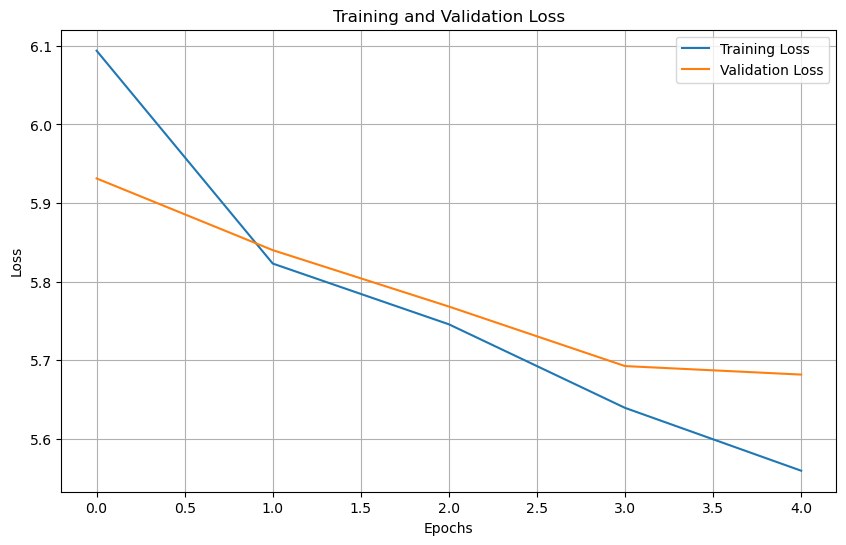

In [18]:
# Initialization
vocab_size = len(vocab)
embedding_dim = 300  # Word2Vec dimension
melody_dim = 7  # Number of melody features
hidden_dim = 512

model = LyricsMelodyGeneratorSimple(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    melody_dim=melody_dim,
    hidden_dim=hidden_dim,
    num_layers=4,
    dropout=0.3,
    pretrained_embeddings=embedding_matrix
).to(device)

# Training
trained_model, train_losses, val_losses = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=5,
    learning_rate=0.00005,
    clip_grad=5.0,
    device=device
)

# Plot training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

### 2.4 Evaluation

In [19]:
def tokenize_for_bleu(lyrics_text):
    processed_lines = []
    lines = str(lyrics_text).lower().split('&')
    for line in lines:
        tokens = re.findall(r"\b\w+(?:'\w+)*\b", line)
        if tokens:
            processed_lines.extend(tokens)
    return processed_lines


def generate_lyrics_for_test(model, melody_data, reverse_vocab, current_start_words, max_length=50, temperature=0.8,
                             device='cpu'):
    """Generate lyrics for a set of test melodies using different starting words."""
    generated_lyrics = {}

    for start_word_token in current_start_words:

        lyrics = model.generate_lyrics(
            melody_data, reverse_vocab,
            max_length=max_length,
            start_word=start_word_token,  # Use the validated start word
            temperature=temperature,
            device=device
        )

        # Collapse repeated <NEXT LINE> into one '\n' and drop <START>/<END>
        formatted_tokens = []
        prev_was_newline = False
        for token in lyrics:
            if token in ('<START>', '<END>'):
                continue
            elif token == '<NEXT LINE>':
                if not prev_was_newline:
                    formatted_tokens.append('\n')
                    prev_was_newline = True
            else:
                formatted_tokens.append(token)
                prev_was_newline = False

        formatted_text = ' '.join(formatted_tokens)
        formatted_text = formatted_text.replace(' \n', '\n').replace('\n ', '\n')

        generated_lyrics[start_word_token] = formatted_text.strip()  # Store with original intended start_word

    return generated_lyrics

In [20]:
base_start_words = ['<START>', 'love', 'hate']
smoothing_function = SmoothingFunction().method4

all_test_results_simple = {}
all_bleu_scores_simple = {}

for test_item in test_mapping:
    print(f"\nGenerating lyrics for (Simple Model): {test_item['artist']} - {test_item['song']}")

    # Extract melody features
    midi_features = load_simple_midi_features(test_item['midi_file'])
    melody_feats = np.array([
        midi_features['avg_pitch'],
        midi_features['pitch_std'],
        midi_features['pitch_range'],
        midi_features['avg_duration'],
        midi_features['avg_velocity'],
        midi_features['note_density'],
        midi_features['tempo'] / 120.0,
    ])

    # Determine the actual first word of the song
    original_lyrics_text = test_item['lyrics']
    first_word_of_song = preprocess_lyrics(pd.Series([original_lyrics_text]))[0][0]

    current_start_words = list(base_start_words)
    if first_word_of_song not in current_start_words:
        current_start_words.append(first_word_of_song)

    print(f"Using start words for this song: {current_start_words}")

    # Generate lyrics with simple model
    test_results = generate_lyrics_for_test(
        model=trained_model,
        melody_data=melody_feats,
        reverse_vocab={v: k for k, v in vocab.items()},
        current_start_words=current_start_words,
        max_length=250,
        temperature=0.9,
        device=device,
    )

    all_test_results_simple[f"{test_item['artist']} - {test_item['song']}"] = test_results

    reference_tokens = tokenize_for_bleu(original_lyrics_text)
    song_bleu_scores = {}

    for start_word, generated_lyrics_text in test_results.items():
        print(f"\nStarting with '{start_word}':")
        print(generated_lyrics_text)

        # BLEU Score
        candidate_tokens = generated_lyrics_text.split()
        if not reference_tokens or not candidate_tokens:
            bleu_score = 0.0
        else:
            bleu_score = sentence_bleu([reference_tokens], candidate_tokens, smoothing_function=smoothing_function)
        song_bleu_scores[start_word] = bleu_score
        print(f"BLEU score: {bleu_score:.4f}")

    all_bleu_scores_simple[f"{test_item['artist']} - {test_item['song']}"] = song_bleu_scores


Generating lyrics for (Simple Model): the_bangles - eternal_flame
Using start words for this song: ['<START>', 'love', 'hate', 'close']

Starting with '<START>':
no i
the be and it's the the
the
here you
you
just
the you
to
how
you
it to me
in the
i the
my when
the and that
slow
you
to
a
i
to
to and
i'm a you i
the my it's me and
you on
just me you i
and
i
it
on got
you
to
you
the
the me me
it
of
to
to
i
to
the you my
the i my
i i up the i
and
you of and
all
to
all it
me in to
a i
you
of to
from of in
of to
you
BLEU score: 0.0076

Starting with 'love':
love little in the it it and
no you and i it's you
songs it's
you
all
to
and
to
the
it
my
the
BLEU score: 0.0012

Starting with 'hate':
hate loud to
me
me
you
the
me
a i'm
and
you
like
you
and
the
we the
i you
a
a
you'll i oh you
to
you
you you
for
to
i'm you
do
to
it the
you then come
the
you
to of and
you of
in
you
with
the
the
i my i the and up me i
in to
of
in
to
to
to
me a relax you you you
with of
it
to
it
to
to and
you
you
and i


## 3.Advanced Model

### 3.1. Dataset


In [22]:
# Helper functions for the advanced dataset
def allocate_line_durations(lines, total_dur):
    """Allocates duration for each line based on number of letters"""
    tokenized_lines = [re.findall(r"\b\w+(?:'\w+)*\b", ln) for ln in lines]
    letter_counts = [sum(len(tok) for tok in toks) for toks in tokenized_lines]
    tot_letters = sum(letter_counts)

    durations = [(cnt / tot_letters) * total_dur for cnt in letter_counts]
    return durations, tokenized_lines


def estimate_word_durations(tokens, line_duration, start_offset=0.0, word_overhead=0.1):
    """Estimates duration of words based on number of letters"""
    total_letters = sum(len(w) for w in tokens)
    total_overhead = word_overhead * len(tokens)
    time_per_letter = (line_duration - total_overhead) / total_letters

    timings, t = [], start_offset
    for w in tokens:
        dur = len(w) * time_per_letter + word_overhead
        timings.append((w, t, t + dur))
        t += dur
    return timings


def extract_time_based_features(midi_data, word_timings):
    """Extract midi features based on word timings"""

    word_features = []

    for word, start_time, end_time in word_timings:
        features = {
            'local_notes': [],
        }

        context_window = 5  # seconds
        start_time = start_time - context_window
        end_time = end_time + context_window

        # Get notes in the specific timing
        for instrument in midi_data.instruments:
            for note in instrument.notes:
                note_overlaps = note.start < end_time and note.end > start_time
                if note_overlaps:
                    features['local_notes'].append({
                        'pitch': note.pitch,
                        'velocity': note.velocity,
                        'duration': note.end - note.start,
                        'overlap': min(note.end, end_time) - max(note.start, start_time)
                    })

        if features['local_notes']:
            features['pitch_mean'] = np.mean([n['pitch'] for n in features['local_notes']])
            features['pitch_std'] = np.std([n['pitch'] for n in features['local_notes']])
            features['velocity_mean'] = np.mean([n['velocity'] for n in features['local_notes']])
            features['duration_mean'] = np.mean([n['duration'] for n in features['local_notes']])
            features['note_density'] = len(features['local_notes'])
        else:
            # if no notes found for this timing
            features['pitch_mean'] = 0
            features['pitch_std'] = 0
            features['velocity_mean'] = 0
            features['duration_mean'] = 0
            features['note_density'] = 0

        word_features.append((word, features))

    return word_features

In [23]:
class LyricsMelodySequenceDataset(Dataset):
    def __init__(self, mappings, vocab, max_sequence_length=50, context_size=3):
        self.mappings = mappings
        self.vocab = vocab
        self.max_sequence_length = max_sequence_length
        self.context_size = context_size
        self.reverse_vocab = {v: k for k, v in vocab.items()}
        self.data = []

        self.process_all_data()

    def process_all_data(self):
        """Prepares data for dataset"""

        for mapping in tqdm(self.mappings, desc="Processing advanced data"):

            midi = pretty_midi.PrettyMIDI(mapping["midi_file"])
            total_dur = midi.get_end_time()
            raw_lines = str(mapping["lyrics"]).lower().split("&")

            # Compute per‑line durations & tokenized lines
            line_durations, tokenized_lines = allocate_line_durations(raw_lines, total_dur)

            # Start from start and pad it to make the first word as target
            full_tokens = ["<START>"] * self.context_size
            dummy_feature = {
                "pitch_mean": 0,
                "pitch_std": 0,
                "velocity_mean": 0,
                "duration_mean": 0,
                "note_density": 0,
            }
            all_word_features = [("<START>", dummy_feature.copy()) for _ in range(self.context_size)]

            # Iterate through lines, keeping an absolute‑time cursor
            current_t = 0.0
            for tokens, ln_dur in zip(tokenized_lines, line_durations):
                if not tokens:  # skip empty line
                    current_t += ln_dur
                    continue

                # Calculate estimation of word timings and use it for time based features calculation
                word_timings = estimate_word_durations(tokens, ln_dur, current_t)
                feats = extract_time_based_features(midi, word_timings)

                full_tokens.extend(tokens)
                all_word_features.extend(feats)

                # Explicitly add <NEXT LINE> token
                full_tokens.append("<NEXT LINE>")
                all_word_features.append(feats[-1])  # reuse last feat

                current_t += ln_dur  # Advance timing

            # Swap last <NEXT LINE> token with <END> token
            full_tokens[-1] = "<END>"

            # Slide a context window to build training examples
            for i in range(self.context_size, len(full_tokens)):
                # Context and target features
                ctx_w = full_tokens[i - self.context_size:i]
                tgt_w = full_tokens[i]
                ctx_f = [all_word_features[j][1] for j in range(i - self.context_size, i)]
                tgt_f = all_word_features[i][1]

                self.data.append({
                    "context_words": ctx_w,
                    "context_features": ctx_f,
                    "target_word": tgt_w,
                    "target_features": tgt_f,
                })

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        unk_idx = self.vocab['<UNK>']

        context_indices = [self.vocab.get(w, unk_idx) for w in item['context_words']]
        target_index = self.vocab.get(item['target_word'], unk_idx)

        # Content midi features
        context_features = []
        for features in item['context_features']:
            feature_vector = np.array([
                features['pitch_mean'] / 127.0,  # Normalize
                features['pitch_std'] / 12.0,  # Normalize
                features['velocity_mean'] / 127.0,  # Normalize
                features['duration_mean'],  # Duration in seconds
                features['note_density'],  # Notes count
            ])
            context_features.append(feature_vector)

        # Target midi features
        target_feature_vector = np.array([[
            item['target_features']['pitch_mean'] / 127.0,
            item['target_features']['pitch_std'] / 12.0,
            item['target_features']['velocity_mean'] / 127.0,
            item['target_features']['duration_mean'],
            item['target_features']['note_density'],
        ]])

        return {
            'context_words': torch.tensor(context_indices, dtype=torch.long),
            'context_features': torch.tensor(np.array(context_features), dtype=torch.float),
            'target_word': torch.tensor(target_index, dtype=torch.long),  # label
            'target_features': torch.tensor(target_feature_vector, dtype=torch.float)
        }

In [24]:
# Create dataset
context_size = 16  # number of context words
advanced_dataset = LyricsMelodySequenceDataset(train_mapping, vocab, context_size=context_size)

# Split into train and validation
adv_train_size = int(0.8 * len(advanced_dataset))
adv_val_size = len(advanced_dataset) - adv_train_size
adv_train_dataset, adv_val_dataset = torch.utils.data.random_split(
    advanced_dataset, [adv_train_size, adv_val_size])

# Create data loaders
adv_train_loader = DataLoader(adv_train_dataset, batch_size=64, shuffle=True)
adv_val_loader = DataLoader(adv_val_dataset, batch_size=64)

print(f"Advanced train dataset size: {len(adv_train_dataset)}")
print(f"Advanced validation dataset size: {len(adv_val_dataset)}")

Processing advanced data:   0%|          | 1/594 [00:00<01:25,  6.92it/s]C:\Users\rusanov\.conda\envs\DRL\Lib\site-packages\pretty_midi\pretty_midi.py:100: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
Processing advanced data: 100%|██████████| 594/594 [02:00<00:00,  4.94it/s]

Advanced train dataset size: 143243
Advanced validation dataset size: 35811


### 3.2. Model

In [25]:
# Helper functions for the model generation
def extract_word_time_features(midi_data, start_time, end_time):
    """Extract features for a word at a specific time window."""
    features = {
        'local_notes': [],
        'pitch_mean': 0,
        'pitch_std': 0,
        'velocity_mean': 0,
        'note_density': 0,
        'duration_mean': 0,
    }

    context_window = 5.0  # seconds
    start_time = start_time - context_window
    end_time = end_time + context_window

    # Extract midi features
    for instrument in midi_data.instruments:
        for note in instrument.notes:
            note_overlaps = note.start < end_time and note.end > start_time

            if note_overlaps:
                features['local_notes'].append({
                    'pitch': note.pitch,
                    'velocity': note.velocity,
                    'duration': note.end - note.start,
                    'overlap': min(note.end, end_time) - max(note.start, start_time)
                })

    if features['local_notes']:
        features['pitch_mean'] = np.mean([n['pitch'] for n in features['local_notes']])
        features['pitch_std'] = np.std([n['pitch'] for n in features['local_notes']])
        features['velocity_mean'] = np.mean([n['velocity'] for n in features['local_notes']])
        features['duration_mean'] = np.mean([n['duration'] for n in features['local_notes']])
        features['note_density'] = len(features['local_notes'])
    else:
        # if no notes found for this timing
        features['pitch_mean'] = 0
        features['pitch_std'] = 0
        features['velocity_mean'] = 0
        features['duration_mean'] = 0
        features['note_density'] = 0

    return features


def create_feature_vector(features):
    """Create a standardized feature vector from extracted features."""
    return np.array([
        features['pitch_mean'] / 127.0,
        features['pitch_std'] / 12.0,
        features['velocity_mean'] / 127.0,
        features['duration_mean'],
        features['note_density'],
    ])

In [26]:
class LyricsMelodyGeneratorAdvanced(nn.Module):
    """Model Definition"""

    def __init__(self, vocab_size, embedding_dim, feature_dim, hidden_dim, context_size, num_layers, dropout,
                 pretrained_embeddings, vocab):
        super(LyricsMelodyGeneratorAdvanced, self).__init__()

        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        self.feature_dim = feature_dim
        self.hidden_dim = hidden_dim
        self.context_size = context_size
        self.num_layers = num_layers
        self.vocab = vocab

        # Word embeddings
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.embedding.weight.data.copy_(torch.from_numpy(pretrained_embeddings))

        # Feature encoder (for musical features)
        self.feature_encoder = nn.Sequential(
            nn.Linear(feature_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # LSTM for sequence modeling - Input: word embeddings + music features for each context word
        lstm_input_dim = embedding_dim + (hidden_dim // 2)
        self.lstm = nn.LSTM(
            input_size=lstm_input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        # Attention layer for context words
        self.attention = nn.MultiheadAttention(hidden_dim, num_heads=4, batch_first=True)

        # Output layer
        final_dim = hidden_dim + hidden_dim + (hidden_dim // 2)
        self.fc = nn.Sequential(
            nn.Linear(final_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, vocab_size)
        )

    def forward(self, context_words, context_features, target_features=None):
        batch_size = context_words.size(0)

        # Word embeddings and Music Features for context words
        word_embeds = self.embedding(context_words)
        music_embeds = self.feature_encoder(context_features)
        combined_input = torch.cat([word_embeds, music_embeds], dim=2)

        # Process with LSTM and self-attention for context words
        lstm_out, (h_n, c_n) = self.lstm(combined_input)
        attn_output, _ = self.attention(lstm_out, lstm_out, lstm_out)

        # Concatenate final hidden state with attention output
        final_hidden = h_n[-1]
        last_attn_output = attn_output[:, -1, :]
        final_repr = torch.cat([final_hidden, last_attn_output], dim=1)

        # Music Features for target word timing
        target_music_embed = self.feature_encoder(target_features).view(batch_size, -1)

        # Output
        final_repr = torch.cat([final_repr, target_music_embed], dim=1)
        output = self.fc(final_repr)

        return output

    def generate_lyrics(self, midi_data, reverse_vocab, max_length=50, start_words=None, temperature=1.0, device='cpu'):
        """Generate lyrics given words and melody features."""
        # Pad with START tokens
        if len(start_words) < self.context_size:
            start_words = ['<START>'] * (self.context_size - len(start_words)) + start_words

        # Output sequence starts with the context words
        output_words = list(start_words)




        # Estimate word duration
        total_duration = midi_data.get_end_time()
        estimated_word_count = max_length
        word_duration = (total_duration / estimated_word_count)

        # Initial context positions
        current_time = 0.0
        word_timings = []
        for word in start_words:
            if word == '<START>':
                word_timings.append((word, current_time, current_time))
            else:
                word_timings.append((word, current_time, current_time + word_duration))
                current_time = current_time + word_duration

        # Extract features for the context words
        context_features_list = []
        for _, start_time, end_time in word_timings:
            features = extract_word_time_features(midi_data, start_time, end_time)
            feature_vector = create_feature_vector(features)
            context_features_list.append(feature_vector)
        context_features = torch.tensor([context_features_list], dtype=torch.float).to(device)

        for _ in range(max_length - len(start_words)):

            # Generate word start and end timings
            tgt_start = current_time
            shift = word_duration + random.uniform(-2, 2)  # add randomness
            tgt_end = current_time + shift

            # Extract target word midi features
            tgt_feat_vec = create_feature_vector(extract_word_time_features(midi_data, tgt_start, tgt_end))
            tgt_feat = torch.tensor([[tgt_feat_vec]], dtype=torch.float, device=device)

            with torch.no_grad():
                output = self.forward(context_tensor, context_features, tgt_feat)

            # Sample word
            output = output.div(temperature)
            word_weights = output.squeeze().exp()
            word_idx = torch.multinomial(word_weights, 1)[0].item()
            word = reverse_vocab[word_idx]

            # If end of output
            if word == '<END>':
                break

            output_words.append(word)
            context_indices = context_indices[1:] + [word_idx]
            context_tensor = torch.tensor([context_indices], dtype=torch.long).to(device)

            current_time += shift  # shift to the next slot

            # Move the context window
            context_features_list = context_features_list[1:] + [tgt_feat_vec]
            context_features = torch.tensor([context_features_list], dtype=torch.float).to(device)

        return output_words

### 3.3. Training

In [27]:
def train_advanced_model(model, train_loader, val_loader, epochs, learning_rate, clip_grad, device):
    """Train the advanced model."""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2, factor=0.5)

    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    best_model = None

    for epoch in range(epochs):

        # Training
        model.train()
        total_loss = 0
        for batch in tqdm(train_loader, desc=f"Epoch {epoch + 1}/{epochs} - Training"):
            optimizer.zero_grad()

            context_words = batch['context_words'].to(device)
            context_features = batch['context_features'].to(device)
            target_word = batch['target_word'].to(device)
            target_features = batch['target_features'].to(device)

            outputs = model(context_words, context_features, target_features)
            loss = criterion(outputs, target_word)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad)
            optimizer.step()

            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation
        model.eval()
        total_val_loss = 0

        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"Epoch {epoch + 1}/{epochs} - Validation"):
                context_words = batch['context_words'].to(device)
                context_features = batch['context_features'].to(device)
                target_word = batch['target_word'].to(device)
                target_features = batch['target_features'].to(device)

                outputs = model(context_words, context_features, target_features)
                loss = criterion(outputs, target_word)

                total_val_loss += loss.item()

        avg_val_loss = total_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        scheduler.step(avg_val_loss)

        print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

        # Save best model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model = model.state_dict().copy()
            print(f"New best model saved!")

    # Load best model
    if best_model is not None:
        model.load_state_dict(best_model)

    return model, train_losses, val_losses

Epoch 1/3 - Validation: 100%|██████████| 560/560 [00:03<00:00, 182.63it/s]


Epoch 1/3, Train Loss: 6.0666, Val Loss: 5.7117
New best model saved!


Epoch 2/3 - Validation: 100%|██████████| 560/560 [00:02<00:00, 194.70it/s]


Epoch 2/3, Train Loss: 5.5597, Val Loss: 5.4353
New best model saved!


Epoch 3/3 - Validation: 100%|██████████| 560/560 [00:02<00:00, 193.53it/s]

Epoch 3/3, Train Loss: 5.2577, Val Loss: 5.2466
New best model saved!


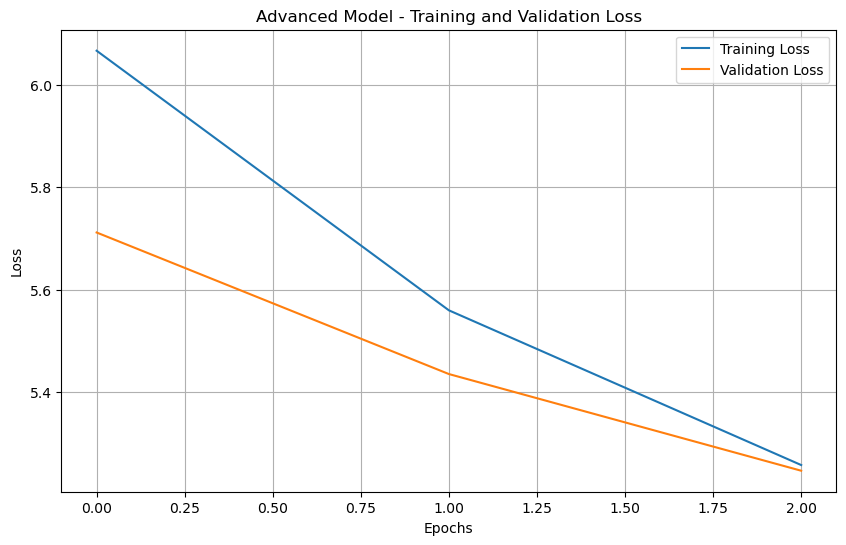

In [28]:
# Initialization
vocab_size = len(vocab)
feature_dim = 5
hidden_dim = 512
num_layers = 4

advanced_model = LyricsMelodyGeneratorAdvanced(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    feature_dim=feature_dim,
    hidden_dim=hidden_dim,
    context_size=context_size,
    num_layers=num_layers,
    dropout=0.3,
    pretrained_embeddings=embedding_matrix,
    vocab=vocab
).to(device)

# Training
trained_advanced_model, adv_train_losses, adv_val_losses = train_advanced_model(
    model=advanced_model,
    train_loader=adv_train_loader,
    val_loader=adv_val_loader,
    epochs=3,
    learning_rate=0.0001,
    clip_grad=5.0,
    device=device
)

# Plot training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(adv_train_losses, label='Training Loss')
plt.plot(adv_val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Advanced Model - Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

### 3.4 Evaluation

In [29]:
def generate_lyrics_with_advanced_model(model, midi_data, reverse_vocab, current_start_words_for_advanced,
                                        max_length=50, temperature=0.8, device='cpu', vocab_map=None):
    """Generate lyrics with advanced model."""
    context_size = model.context_size
    generated_lyrics = {}

    for start_word_token in current_start_words_for_advanced:

        # Pad context window
        initial_context_words = ['<START>'] * (context_size - 1) + [start_word_token]

        lyrics_tokens = model.generate_lyrics(
            midi_data=midi_data,
            reverse_vocab=reverse_vocab,
            max_length=max_length,
            start_words=initial_context_words,
            temperature=temperature,
            device=device,
        )

        # Collapse repeated <NEXT LINE> into one '\n', drop <START>/<END>
        formatted_tokens = []
        prev_was_newline = False

        for token in lyrics_tokens:
            if token in ('<START>', '<END>'):
                continue
            elif token == '<NEXT LINE>':
                if not prev_was_newline:
                    formatted_tokens.append('\n')
                    prev_was_newline = True
            else:
                formatted_tokens.append(token)
                prev_was_newline = False

        formatted_text = ' '.join(formatted_tokens)
        formatted_text = formatted_text.replace(' \n', '\n').replace('\n ', '\n')

        generated_lyrics[start_word_token] = formatted_text.strip()

    return generated_lyrics

In [30]:
all_test_results_advanced = {}
all_bleu_scores_advanced = {}

for test_item in test_mapping:  # Ensure test_mapping is defined
    print(f"\nGenerating lyrics for (Advanced Model): {test_item['artist']} - {test_item['song']}")

    # Extract melody features (MIDI data object for advanced model)
    midi_data = pretty_midi.PrettyMIDI(test_item['midi_file'])  # Ensure pretty_midi is imported and works

    # Determine the first word of the song
    original_lyrics_text = test_item['lyrics']
    first_word_of_song = preprocess_lyrics(pd.Series([original_lyrics_text]))[0][0]

    current_start_words_for_advanced = list(base_start_words)
    if first_word_of_song and first_word_of_song not in current_start_words_for_advanced and first_word_of_song in vocab:
        current_start_words_for_advanced.append(first_word_of_song)

    print(f"Using start words for this song: {current_start_words_for_advanced}")

    # Generate lyrics with advanced model
    test_results = generate_lyrics_with_advanced_model(
        model=trained_advanced_model,
        midi_data=midi_data,
        reverse_vocab={v: k for k, v in vocab.items()},
        current_start_words_for_advanced=current_start_words_for_advanced,
        max_length=250,
        temperature=0.9,
        device=device,
        vocab_map=vocab
    )
    all_test_results_advanced[f"{test_item['artist']} - {test_item['song']}"] = test_results

    # Prepare reference for BLEU
    reference_tokens = tokenize_for_bleu(original_lyrics_text)
    song_bleu_scores = {}

    # Print generated lyrics and calculate BLEU and Rhyme scores
    for start_word, generated_lyrics_text in test_results.items():
        print(f"\nStarting with '{start_word}':")
        print(generated_lyrics_text)

        # BLEU Score
        candidate_tokens = generated_lyrics_text.split()
        if not reference_tokens or not candidate_tokens:
            bleu_score = 0.0
        else:
            bleu_score = sentence_bleu([reference_tokens], candidate_tokens, smoothing_function=smoothing_function)
        song_bleu_scores[start_word] = bleu_score
        print(f"BLEU score: {bleu_score:.4f}")

    all_bleu_scores_advanced[f"{test_item['artist']} - {test_item['song']}"] = song_bleu_scores


Generating lyrics for (Advanced Model): the_bangles - eternal_flame
Using start words for this song: ['<START>', 'love', 'hate', 'close']


C:\Users\rusanov\AppData\Local\Temp\ipykernel_42472\4085553717.py:112: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\cb\pytorch_1000000000000\work\torch\csrc\utils\tensor_new.cpp:281.)
  context_features = torch.tensor([context_features_list], dtype=torch.float).to(device)



Starting with '<START>':
reaches down and the stupid bones
your best swear to made to dance
keep a baby sea
ninety people away
if that the yo sail
and is reindeer all space and i've got show
there's latino finally key
i'll got is the devil uh montreal
and the he shady forever
all you got ain't can too better
i all to right
if i know to just for we you'll what heard
up it true in this said all gonna come we do
let's mean a matter
you love on my push
i
can know me bring her last river
then how i have me them a body
BLEU score: 0.0071

Starting with 'love':
love my love to you
i know in there
but that i know you you will
i one no night
it's i you got again with on
no true sure could know
you'll feel my i'm i left the thing
you say this knew to my shit
ah have my own y'all
try you get really look
let's someone anybody somebody they know me
oh won't i'd know that you can't fall
simple y'all as come baby and do
i could i feel long my love
i never all to thought to you
i mind a share caught 

## 4. Summary

### 4.1. Comparative Analysis

In [31]:
def avg_length(lyrics_dict):
    """Calculates average length of generated lyrics"""
    total_length = 0
    count = 0
    for song, results in lyrics_dict.items():
        for start_word, lyrics in results.items():
            words = lyrics.split()
            total_length += len(words)
            count += 1
    return total_length / count if count > 0 else 0


def calculate_average_bleu(all_bleu_scores_dict):
    """Calculate and print average BLEU scores"""
    scores_list = []
    for song_name, start_word_scores in all_bleu_scores_dict.items():
        for start_word, score in start_word_scores.items():
            scores_list.append(score)
    return np.mean(scores_list) if scores_list else 0.0


simple_avg_length = avg_length(all_test_results_simple)
advanced_avg_length = avg_length(all_test_results_advanced)

print(f"Simple Model - Average Generated Length: {simple_avg_length:.2f} words")
print(f"Advanced Model - Average Generated Length: {advanced_avg_length:.2f} words")

# Calculate average BLEU scores
avg_bleu_simple = calculate_average_bleu(all_bleu_scores_simple)
avg_bleu_advanced = calculate_average_bleu(all_bleu_scores_advanced)

print(f"\nSimple Model - Average BLEU Score: {avg_bleu_simple:.4f}")
print(f"Advanced Model - Average BLEU Score: {avg_bleu_advanced:.4f}")

Simple Model - Average Generated Length: 77.10 words
Advanced Model - Average Generated Length: 146.11 words

Simple Model - Average BLEU Score: 0.0031
Advanced Model - Average BLEU Score: 0.0070


### 4.2 Save Models and Results

In [61]:
# Save models (Ensure trained_model, trained_advanced_model, vocab, embedding_matrix are defined)
torch.save({
    'model_state_dict': trained_model.state_dict(),
    'vocab': vocab,
    'embedding_matrix': embedding_matrix
}, 'simple_lyrics_model.pth')
print("Simple model saved!")

torch.save({
    'model_state_dict': trained_advanced_model.state_dict(),
    'vocab': vocab,
    'embedding_matrix': embedding_matrix
}, 'advanced_lyrics_model.pth')
print("Advanced model saved!")

# Save generated lyrics with scores
output_filename = 'generated_lyrics_results_with_scores.txt'
with open(output_filename, 'w', encoding='utf-8') as f:
    f.write("==== SIMPLE MODEL RESULTS ====\n\n")
    for song, results in all_test_results_simple.items():  # song is song_name here
        f.write(f"Song: {song}\n")
        for start_word, lyrics_text in results.items():  # lyrics_text is the generated string
            bleu_s = all_bleu_scores_simple.get(song, {}).get(start_word, "N/A")
            bleu_s_str = f"{bleu_s:.4f}" if isinstance(bleu_s, float) else bleu_s
            f.write(f"Starting with '{start_word}' (BLEU: {bleu_s_str}):\n")
            f.write(f"{lyrics_text}\n\n")

    f.write("\n\n==== ADVANCED MODEL RESULTS ====\n\n")
    for song, results in all_test_results_advanced.items():  # song is song_name here
        f.write(f"Song: {song}\n")
        for start_word, lyrics_text in results.items():  # lyrics_text is the generated string
            bleu_a = all_bleu_scores_advanced.get(song, {}).get(start_word, "N/A")
            bleu_a_str = f"{bleu_a:.4f}" if isinstance(bleu_a, float) else bleu_a
            f.write(f"Starting with '{start_word}' (BLEU: {bleu_a_str}):\n")
            f.write(f"{lyrics_text}\n\n")

    f.write("\n\n==== AVERAGE SCORES ====\n")
    f.write(f"Simple Model - Average BLEU: {avg_bleu_simple:.4f}\n")
    f.write(f"Advanced Model - Average BLEU: {avg_bleu_advanced:.4f}\n")

print(f"Generated lyrics results with scores saved to '{output_filename}'")

Simple model saved!
Advanced model saved!
Generated lyrics results with scores saved to 'generated_lyrics_results_with_scores.txt'
